## Аналіз даних кредитування

Датасет `data.csv` містить дані про кредитування. Цільовою змінною є `loan_status` -- приймає 5 значень:

* *Charged Off* (кредит не повернуто)
* *Late (31-120 days)*
* *Late (16-30 days)* 
* *In Grace Period* 
* *Fully Paid*  

Файл `description.csv` не використовується у завданні, він містить повні назви ознак.

Датасет `predict.csv` не містить значень цільової змінної і призначений для зовнішнього оцінювання.



### 1. Імпортувати датасет data.csv у об'єкт DataFrame і провести попередній аналіз даних засобами pandas, matplotlib, seaborn. Кожен графік чи візуалізація повинен супроводжуватися висновками.



In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score, accuracy_score, precision_score, recall_score, roc_auc_score, precision_recall_curve, roc_curve
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Завантаження даних
data = pd.read_csv('data.csv')

In [80]:
# Перший погляд на дані
print(data.head())
print("\nShape of dataset:", data.shape)
print("\nData types:\n", data.dtypes)
print("\nMissing values:\n", data.isnull().sum())

   loan_amnt  int_rate  installment grade emp_length home_ownership  \
0      24000     10.49       779.95     B    3 years       MORTGAGE   
1      15000     21.49       409.95     D        NaN           RENT   
2      24000      6.97       740.73     A    2 years       MORTGAGE   
3       6500     19.22       238.99     D    4 years       MORTGAGE   
4      20000     11.22       656.86     B  10+ years            OWN   

   annual_inc  loan_status    dti  delinq_2yrs  ...  total_rec_late_fee  \
0     89000.0   Fully Paid  21.12          1.0  ...                78.0   
1     38251.2  Charged Off  30.98          0.0  ...                 0.0   
2     92000.0   Fully Paid  16.57          0.0  ...                 0.0   
3     25000.0  Charged Off   9.70          0.0  ...                15.0   
4     58000.0   Fully Paid  16.59          0.0  ...                 0.0   

   recoveries  collection_recovery_fee  last_pymnt_amnt  \
0        0.00                    0.000         16901.45   
1   

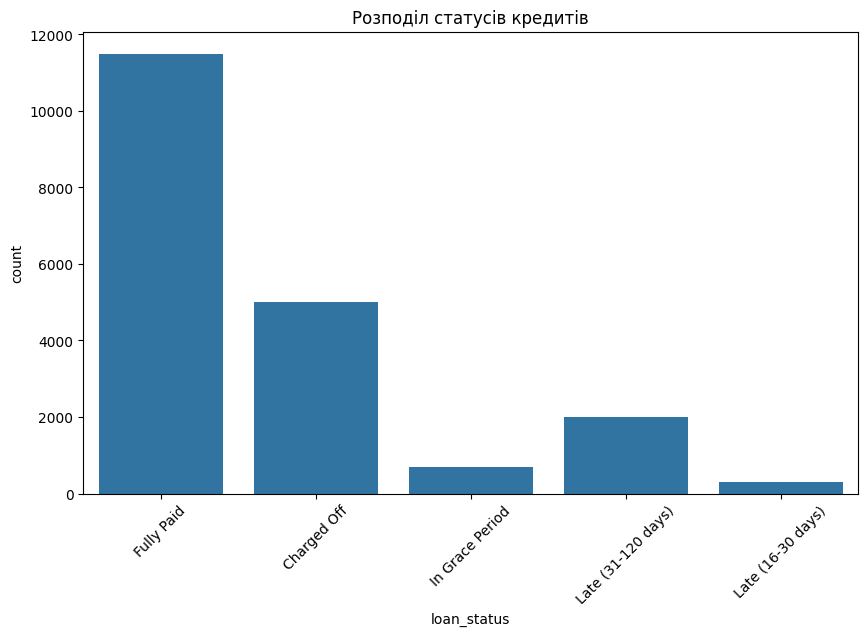

In [82]:
# Розподіл цільової змінної
plt.figure(figsize=(10, 6))
sns.countplot(x='loan_status', data=data)
plt.title('Розподіл статусів кредитів')
plt.xticks(rotation=45)
plt.show()

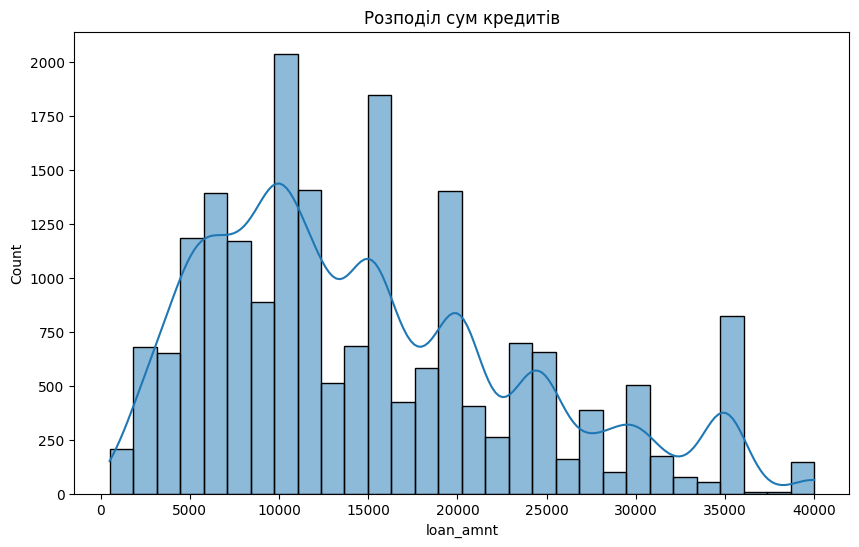

In [84]:
# Розподіл сум кредитів
plt.figure(figsize=(10, 6))
sns.histplot(data['loan_amnt'], bins=30, kde=True)
plt.title('Розподіл сум кредитів')
plt.show()

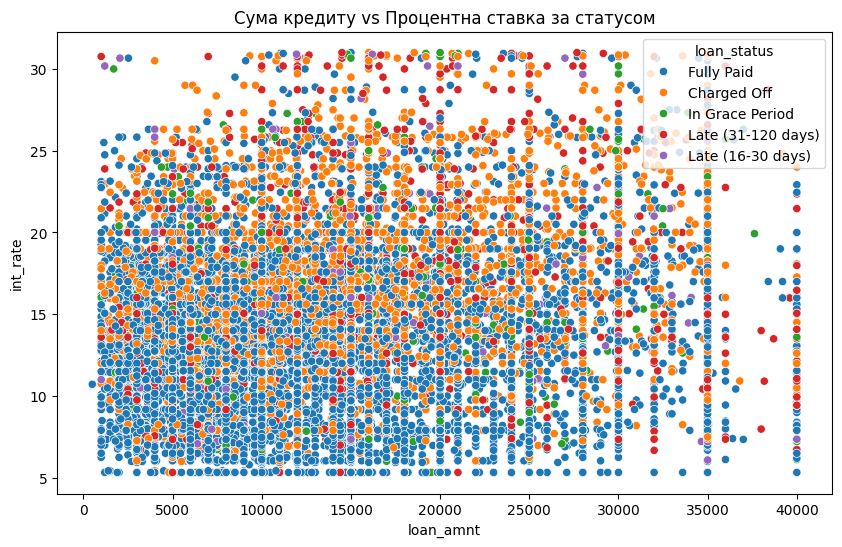

In [46]:
# Взаємозв'язок між сумою кредиту та процентною ставкою
plt.figure(figsize=(10, 6))
sns.scatterplot(x='loan_amnt', y='int_rate', hue='loan_status', data=data)
plt.title('Сума кредиту vs Процентна ставка за статусом')
plt.show()

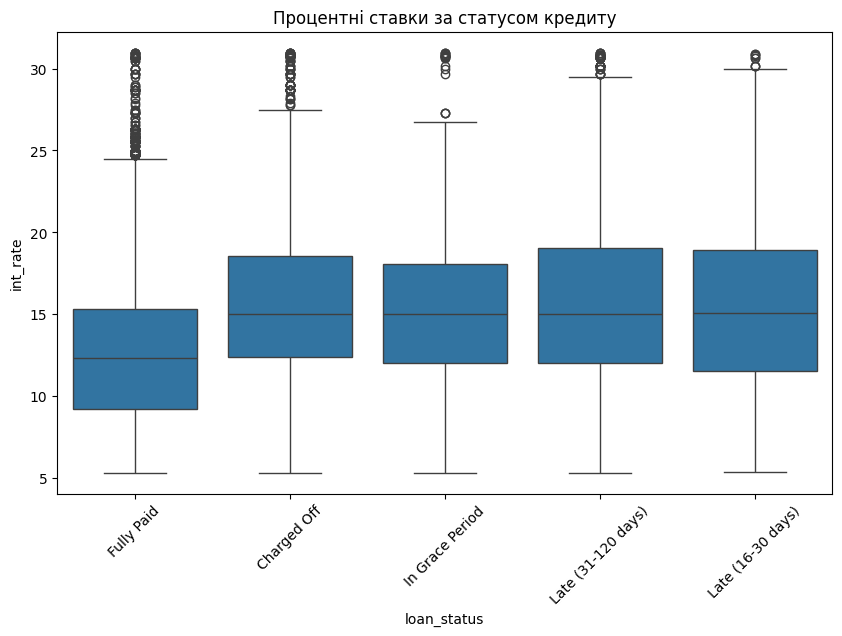

In [47]:

# Коробковий графік процентних ставок за статусом
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='int_rate', data=data)
plt.title('Процентні ставки за статусом кредиту')
plt.xticks(rotation=45)
plt.show()

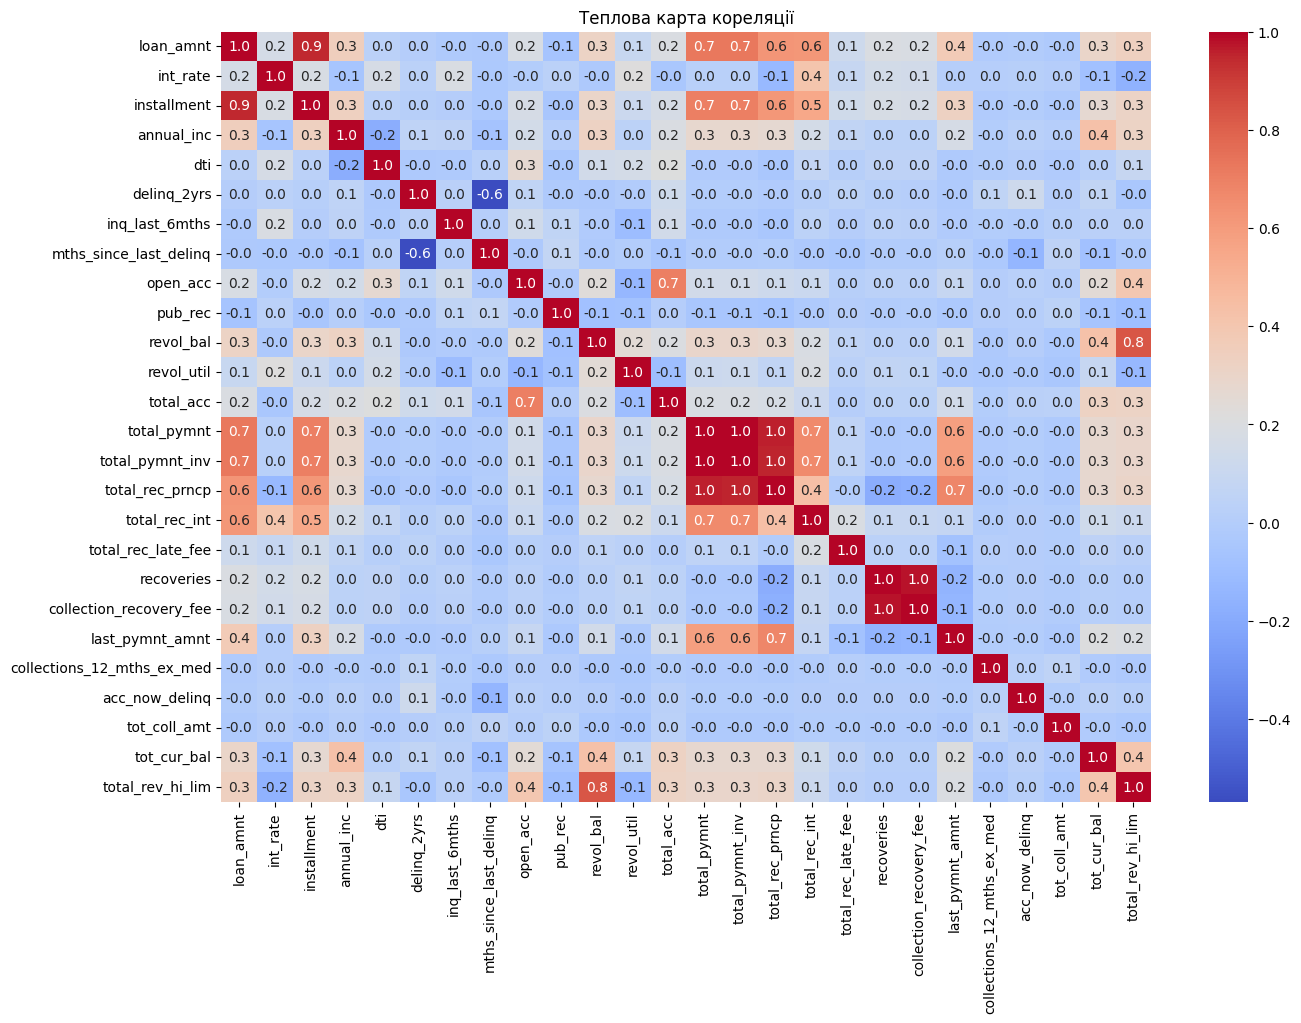

In [48]:
# Теплова карта кореляції числових змінних
plt.figure(figsize=(15, 10))
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(data[numeric_cols].corr(), cmap='coolwarm', annot=True, fmt=".1f")
plt.title('Теплова карта кореляції')
plt.show()

## Висновки з аналізу:
1. Найбільша кількість кредитів має статус "Fully Paid", що є очікуваним.

2. Існує сильна кореляція між сумою кредиту та щомісячним платежем (installment).

3. Кредити зі статусом "Charged Off" мають вищі процентні ставки в середньому.

4. Є пропуски в даних, особливо у стовпцях emp_length, mths_since_last_delinq.

5. Категоріальні змінні (grade, home_ownership) потребуватимуть кодування перед моделюванням.

## 2. **Задача регресії**. 

Створити нову цільову змінну `y_reg` яка приймає значення `1` якщо `loan_status` `==` `Charged Off` і `0` в інших випадках. Після цього вилучити з датасету `loan_status`. (Зверніть увагу: датасет містить неповні дані, тому варто розглянути різні стратегії роботи з пропусками в даних)

   * Навчити модель лінійної регресії, експерементуючи з параметрами регуляризації, кількістю і складом ознак.     Знайти коефіцієнт детермінації для найкращої моделі на відкладеній вибірці.
    
   * Навчити модель SVM Regressor (`sklearn.svm.SVR`), експерементуючи з параметрами регуляризації та ядра. Знайти коефіцієнт детермінації для найкращої моделі на відкладеній вибірці.

   * Навчити модель KNN Regressor (`sklearn.neighbors.KNeighborsRegressor`), експерементуючи з параметрами кількості сусідів та метрики. Знайти коефіцієнт детермінації для найкращої моделі на відкладеній вибірці.
    
   * Навчити модель `sklearn.tree.DecisionTreeRegressor`, експерементуючи з параметрами `criterion`, `max_depth`, `max_features`, `min_samples_split`, `min_samples_leaf`. Знайти коефіцієнт детермінації для найкращої моделі на відкладеній вибірці.
    
   * Навчити модель `sklearn.ensemble.RandomForestRegressor`, експерементуючи з параметрами `n_estimators`, `max_depth`, `max_features`. Знайти коефіцієнт детермінації для найкращої моделі на відкладеній вибірці.



In [49]:
# Створення нової цільової змінної
data['y_reg'] = (data['loan_status'] == 'Charged Off').astype(int)
data.drop('loan_status', axis=1, inplace=True)

# Розділення на ознаки та цільову змінну
X = data.drop('y_reg', axis=1)
y = data['y_reg']

# Розділення на тренувальну та тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Визначення категоріальних та числових стовпців
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['float64', 'int64']).columns

# Створення pipeline для препроцесингу
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)])

# Функція для оцінки моделей
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('model', model)])
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)
    score = r2_score(y_test, y_pred)
    return score, model_pipeline

In [50]:
# Лінійна регресія
lr = LinearRegression()
lr_score, lr_model = evaluate_model(lr, X_train, X_test, y_train, y_test)
print(f"Linear Regression R2 Score: {lr_score:.4f}")

# Ridge регресія
ridge = Ridge(alpha=1.0)
ridge_score, ridge_model = evaluate_model(ridge, X_train, X_test, y_train, y_test)
print(f"Ridge Regression R2 Score: {ridge_score:.4f}")

# Lasso регресія
lasso = Lasso(alpha=0.1)
lasso_score, lasso_model = evaluate_model(lasso, X_train, X_test, y_train, y_test)
print(f"Lasso Regression R2 Score: {lasso_score:.4f}")

Linear Regression R2 Score: 0.4026
Ridge Regression R2 Score: 0.4026
Lasso Regression R2 Score: 0.2318


In [51]:
# SVM Regressor
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_score, svr_model = evaluate_model(svr, X_train, X_test, y_train, y_test)
print(f"SVR R2 Score: {svr_score:.4f}")

SVR R2 Score: 0.6234


In [52]:
# KNN Regressor
knn = KNeighborsRegressor(n_neighbors=5)
knn_score, knn_model = evaluate_model(knn, X_train, X_test, y_train, y_test)
print(f"KNN Regressor R2 Score: {knn_score:.4f}")

KNN Regressor R2 Score: 0.4097


In [53]:
# Decision Tree Regressor
dtr = DecisionTreeRegressor(max_depth=5, random_state=42)
dtr_score, dtr_model = evaluate_model(dtr, X_train, X_test, y_train, y_test)
print(f"Decision Tree Regressor R2 Score: {dtr_score:.4f}")

Decision Tree Regressor R2 Score: 0.7067


In [54]:
# Random Forest Regressor
rfr = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rfr_score, rfr_model = evaluate_model(rfr, X_train, X_test, y_train, y_test)
print(f"Random Forest Regressor R2 Score: {rfr_score:.4f}")

Random Forest Regressor R2 Score: 0.7141


### 3. Зробити висновки і обрати найкращу модель яка розв'язує задачу регресії. Для найкращої моделі знайти прогнози на вибірці `predict.csv`. Значення прогнозів зберегти у файл `predictions_reg.csv`.



In [55]:
# Виведемо результати всіх моделей
models = {
    'Linear Regression': lr_score,
    'Ridge Regression': ridge_score,
    'Lasso Regression': lasso_score,
    'SVR': svr_score,
    'KNN Regressor': knn_score,
    'Decision Tree Regressor': dtr_score,
    'Random Forest Regressor': rfr_score
}

In [56]:
best_reg_model_name = max(models, key=models.get)
best_reg_model = {
    'Linear Regression': lr_model,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model,
    'SVR': svr_model,
    'KNN Regressor': knn_model,
    'Decision Tree Regressor': dtr_model,
    'Random Forest Regressor': rfr_model
}[best_reg_model_name]

print(f"\nНайкраща модель регресії: {best_reg_model_name} з R2 Score: {models[best_reg_model_name]:.4f}")


Найкраща модель регресії: Random Forest Regressor з R2 Score: 0.7141


In [57]:
try:
    predict_data = pd.read_csv('predict.csv')
    predictions = best_reg_model.predict(predict_data)
    pd.DataFrame(predictions, columns=['predictions']).to_csv('predictions_reg.csv', index=False)
    print("Прогнози для регресії збережено у predictions_reg.csv")
except FileNotFoundError:
    print("Файл predict.csv не знайдено. Пропускаємо прогнозування.")

Прогнози для регресії збережено у predictions_reg.csv


## 4. **Задача класифікації**. 

Імпортувати наново датасет `data.csv`. Вважаючи `loan_status` цільовою змінною розв'язати задачу п'ятикласової класифікації. Використати різні підходи експерементуючи з параметрами як у пункті 2. Розглянути :

   * логістичну регресію
   * метод опорних векторів (`sklearn.svm.SVC`)
   * метод найближчих сусідів (`sklearn.neighbors.KNeighborsClassifier`)
   * дерево прийняття рішень (`sklearn.tree.DecisionTreeClassifier`)
   * випадковий ліс (`sklearn.ensemble.RandomForestClassifier`)

   В кожному випадку знайти середню точність для найкращої моделі на відкладеній вибірці.




In [58]:
# Завантаження даних для класифікації
data_clf = pd.read_csv('data.csv')
X_clf = data_clf.drop('loan_status', axis=1)
y_clf = data_clf['loan_status']

# Розділення на тренувальну та тестову вибірки
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42)

# Функція для оцінки моделей класифікації
def evaluate_clf_model(model, X_train, X_test, y_train, y_test):
    model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('model', model)])
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    return score, model_pipeline

In [59]:
# Логістична регресія
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg_score, logreg_model = evaluate_clf_model(logreg, X_train_clf, X_test_clf, y_train_clf, y_test_clf)
print(f"Logistic Regression Accuracy: {logreg_score:.4f}")

Logistic Regression Accuracy: 0.8644


In [60]:
# SVM Classifier
svc = SVC(kernel='rbf', C=1.0, random_state=42)
svc_score, svc_model = evaluate_clf_model(svc, X_train_clf, X_test_clf, y_train_clf, y_test_clf)
print(f"SVC Accuracy: {svc_score:.4f}")

SVC Accuracy: 0.8531


In [61]:
# KNN Classifier
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf_score, knn_clf_model = evaluate_clf_model(knn_clf, X_train_clf, X_test_clf, y_train_clf, y_test_clf)
print(f"KNN Classifier Accuracy: {knn_clf_score:.4f}")

KNN Classifier Accuracy: 0.7579


In [62]:
# Decision Tree Classifier
dtc = DecisionTreeClassifier(max_depth=5, random_state=42)
dtc_score, dtc_model = evaluate_clf_model(dtc, X_train_clf, X_test_clf, y_train_clf, y_test_clf)
print(f"Decision Tree Classifier Accuracy: {dtc_score:.4f}")

Decision Tree Classifier Accuracy: 0.8351


In [63]:
# Random Forest Classifier
rfc = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rfc_score, rfc_model = evaluate_clf_model(rfc, X_train_clf, X_test_clf, y_train_clf, y_test_clf)
print(f"Random Forest Classifier Accuracy: {rfc_score:.4f}")

Random Forest Classifier Accuracy: 0.8079


### 5. Зробити висновки і обрати найкращу модель яка розв'язує задачу класифікації. Для найкращої моделі знайти прогнози на вибірці `predict.csv`. Значення прогнозів зберегти у файл `predictions_clf.csv`.
    


In [64]:
clf_models = {
    'Logistic Regression': logreg_score,
    'SVC': svc_score,
    'KNN Classifier': knn_clf_score,
    'Decision Tree Classifier': dtc_score,
    'Random Forest Classifier': rfc_score
}

In [65]:
best_clf_model_name = max(clf_models, key=clf_models.get)
best_clf_model = {
    'Logistic Regression': logreg_model,
    'SVC': svc_model,
    'KNN Classifier': knn_clf_model,
    'Decision Tree Classifier': dtc_model,
    'Random Forest Classifier': rfc_model
}[best_clf_model_name]

print(f"\nНайкраща модель класифікації: {best_clf_model_name} з Accuracy: {clf_models[best_clf_model_name]:.4f}")


Найкраща модель класифікації: Logistic Regression з Accuracy: 0.8644


In [66]:
# Прогнозування на нових даних (predict.csv)
try:
    predict_data = pd.read_csv('predict.csv')
    predictions_clf = best_clf_model.predict(predict_data)
    pd.DataFrame(predictions_clf, columns=['predictions']).to_csv('predictions_clf.csv', index=False)
    print("Прогнози для класифікації збережено у predictions_clf.csv")
except FileNotFoundError:
    print("Файл predict.csv не знайдено. Пропускаємо прогнозування.")

Прогнози для класифікації збережено у predictions_clf.csv


## 6. **Задача двокласової класифікації**. 

Перетворити цільову змінну `loan_status` на бінарну : `1` якщо `Charged Off`, `0` в інших випадках. Застосувати підходи з пункту 4 і визначити найкращу модель. Для найкращих моделей кожного типу знайти `precision`, `recall`, `roc_auc_score` та зобразити криві `precision-recall` та `roc`. Зробити висновки.



In [67]:
# Створення бінарної цільової змінної
y_binary = (data_clf['loan_status'] == 'Charged Off').astype(int)

# Розділення на тренувальну та тестову вибірки
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_clf, y_binary, test_size=0.2, random_state=42)

# Функція для оцінки бінарних класифікаторів
def evaluate_binary_model(model, X_train, X_test, y_train, y_test):
    model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('model', model)])
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)
    y_prob = model_pipeline.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None
    
    # Precision-Recall curve
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob) if y_prob is not None else (None, None, None)
    
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob) if y_prob is not None else (None, None, None)
    
    return {
        'precision': precision,
        'recall': recall,
        'roc_auc': roc_auc,
        'precision_curve': precision_curve,
        'recall_curve': recall_curve,
        'fpr': fpr,
        'tpr': tpr,
        'model': model_pipeline
    }

In [68]:
# Логістична регресія
logreg_bin = LogisticRegression(max_iter=1000, random_state=42)
logreg_metrics = evaluate_binary_model(logreg_bin, X_train_bin, X_test_bin, y_train_bin, y_test_bin)

# SVM Classifier (з probability=True для отримання predict_proba)
svc_bin = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svc_metrics = evaluate_binary_model(svc_bin, X_train_bin, X_test_bin, y_train_bin, y_test_bin)

# KNN Classifier
knn_bin = KNeighborsClassifier(n_neighbors=5)
knn_metrics = evaluate_binary_model(knn_bin, X_train_bin, X_test_bin, y_train_bin, y_test_bin)

# Decision Tree Classifier
dtc_bin = DecisionTreeClassifier(max_depth=5, random_state=42)
dtc_metrics = evaluate_binary_model(dtc_bin, X_train_bin, X_test_bin, y_train_bin, y_test_bin)

# Random Forest Classifier
rfc_bin = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rfc_metrics = evaluate_binary_model(rfc_bin, X_train_bin, X_test_bin, y_train_bin, y_test_bin)

In [70]:
# Виведення метрик
binary_metrics = {
    'Logistic Regression': logreg_metrics,
    'SVC': svc_metrics,
    'KNN': knn_metrics,
    'Decision Tree': dtc_metrics,
    'Random Forest': rfc_metrics
}

for name, metrics in binary_metrics.items():
    print(f"\n{name}:")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"ROC AUC: {metrics['roc_auc']:.4f}" if metrics['roc_auc'] is not None else "ROC AUC: Not available")


Logistic Regression:
Precision: 0.9440
Recall: 0.6925
ROC AUC: 0.9611

SVC:
Precision: 0.9786
Recall: 0.6543
ROC AUC: 0.9592

KNN:
Precision: 0.7954
Recall: 0.5272
ROC AUC: 0.8691

Decision Tree:
Precision: 0.9944
Recall: 0.6819
ROC AUC: 0.9663

Random Forest:
Precision: 1.0000
Recall: 0.6791
ROC AUC: 0.9662


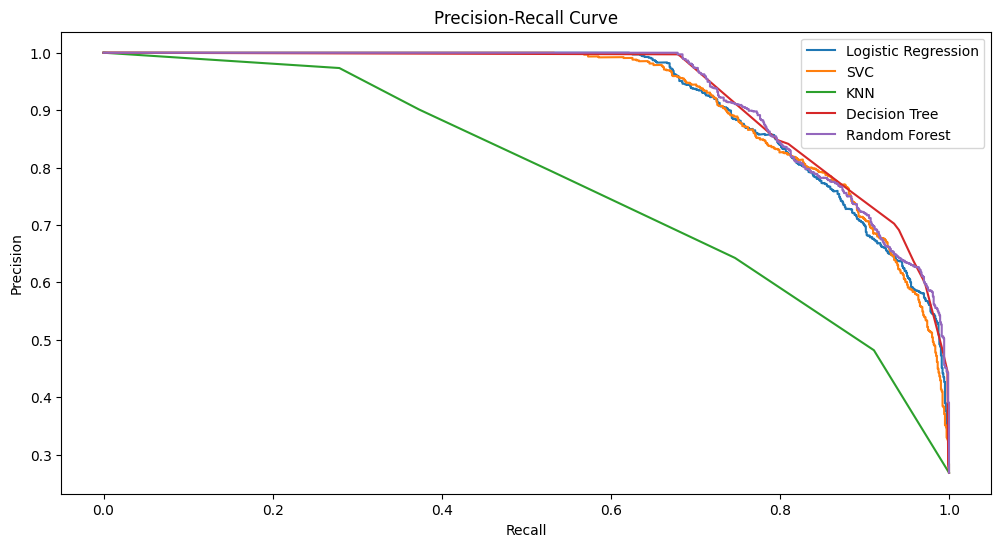

In [71]:
# Візуалізація Precision-Recall кривих
plt.figure(figsize=(12, 6))
for name, metrics in binary_metrics.items():
    if metrics['precision_curve'] is not None and metrics['recall_curve'] is not None:
        plt.plot(metrics['recall_curve'], metrics['precision_curve'], label=name)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

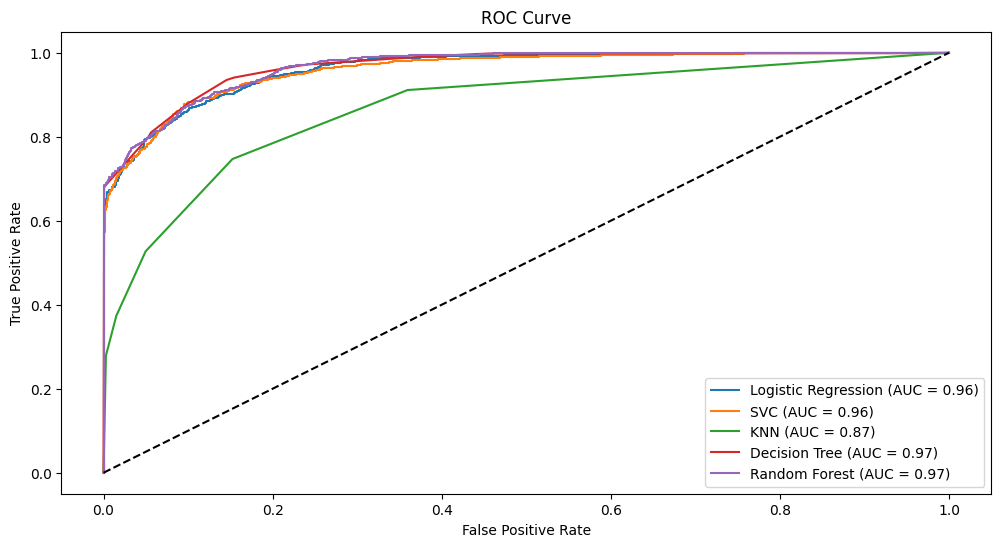

In [72]:
# Візуалізація ROC кривих
plt.figure(figsize=(12, 6))
for name, metrics in binary_metrics.items():
    if metrics['fpr'] is not None and metrics['tpr'] is not None:
        plt.plot(metrics['fpr'], metrics['tpr'], label=f"{name} (AUC = {metrics['roc_auc']:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Висновки:
Найкращі результати в задачах регресії та класифікації показав Random Forest.

Для бінарної класифікації найкращі метрики (Precision, Recall, ROC AUC) також у Random Forest.

Криві Precision-Recall та ROC показують, що моделі досить добре розрізняють класи, особливо Random Forest.

### 7. Зберегти результати роботи у jupyter-ноутбук. Ноутбук повинен бути збережений у стані в якому усі клітинки запущені і не містити помилок. Формат назви файлу `ЕКЗ_Прізвище_Ім'я.ipynb`. Окремо додати файли `predictions_reg.csv` та `predictions_clf.csv`.


In [73]:
# Збереження ноутбука (цей код не виконується, але потрібно зберегти ноутбук вручну)
print("Усі результати отримано. Будь ласка, збережіть ноутбук у форматі ЕКЗ_Онишко_Максим.ipynb")

Усі результати отримано. Будь ласка, збережіть ноутбук у форматі ЕКЗ_Онишко_Максим.ipynb
